In [141]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
from pathlib import Path 
import glob, os
import numpy as np

In [142]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def load_vanhateren_raw(path, dtype=np.float32):
    """
    Load Van Hateren .iml or .imc binary image as raw linear luminance.
    """
    path = Path(path)
    raw = np.fromfile(path, dtype=">u2")  # big-endian uint16

    if raw.size == 1024 * 1536:
        img = raw.reshape((1024, 1536))

    elif raw.size == 768 * 1024:
        img = raw.reshape((768, 1024))

    else:
        raise ValueError(
            f"Unexpected size for {path.name}: {raw.size} uint16 values"
        )

    return img.astype(dtype)


def scale_luminance(img, percentile_scale=99, clip=True, eps=1e-8):
    """
    Scale image for training after filtering.
    """
    img = img.astype(np.float32)

    if percentile_scale is not None:
        scale = np.percentile(img, percentile_scale)
        img = img / (scale + eps)

    if clip:
        img = np.clip(img, 0, 1)

    return img.astype(np.float32)

In [168]:
dpp = 1 / 60
n_images = 700

data_path = Path("vanhateren_iml/")
iml_files = np.array(sorted(data_path.glob("*.iml")), dtype=object)
rng = np.random.default_rng(0)

local_selected = rng.choice(len(iml_files), size=n_images, replace=False)

selected_files = iml_files[local_selected]\



In [169]:
images = np.stack(
    [
        scale_luminance(
            load_vanhateren_raw(f),
            percentile_scale=99,
            clip=True,
        )
        for f in selected_files
    ],
    axis=0,
)

In [170]:
def show_hdr(img, ax=None, mode="log", lo=1, hi=99.5, title=None,
             extent=None, horizon_row=None):
    """Display-only tone map. Input: raw or scaled linear radiance."""
    x = np.asarray(img, dtype=np.float64)
    pos = x[x > 0]
    floor = np.percentile(pos, 0.1) if pos.size else 1e-8

    if mode == "log":
        y = np.log10(np.maximum(x, floor))
    elif mode == "gamma":
        y = np.power(np.maximum(x, 0) / np.percentile(x, hi), 1 / 2.2)
    else:
        y = x

    vmin, vmax = np.percentile(y, [lo, hi])
    ax = ax or plt.gca()
    ax.imshow(y, cmap="gray", vmin=vmin, vmax=vmax,
              interpolation="nearest", aspect="equal", extent=extent)
    if horizon_row is not None:
        ax.axhline(horizon_row, color="tab:red", lw=0.5)
    if title:
        ax.set_title(title, fontsize=8)
    ax.set_axis_off()
    return ax


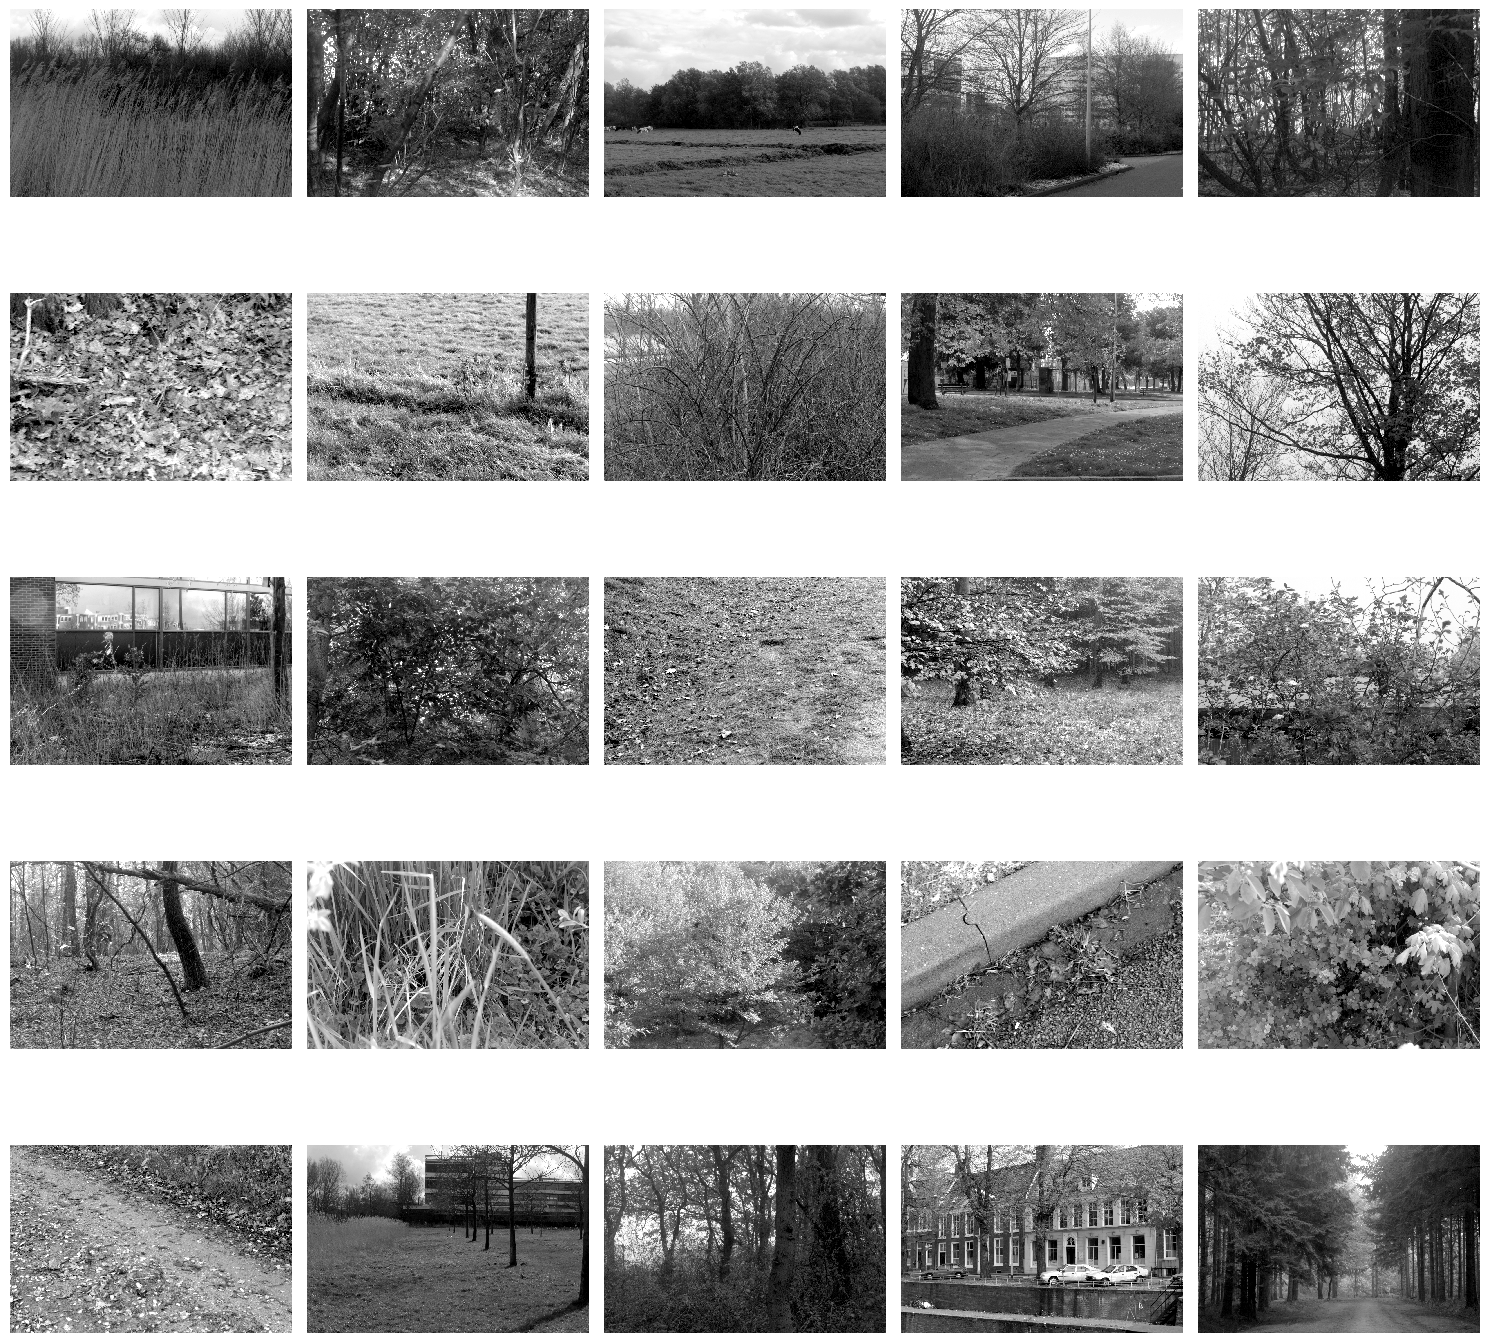

In [171]:
n_rows = 5
n_cols = 5
n_samples = n_rows * n_cols

fig, axes = plt.subplots(
    n_rows, 
    n_cols, 
    figsize=(3 * n_cols, 3 * n_rows)
)

axes = np.atleast_2d(axes)

for idx, ax in enumerate(axes.flat[:n_samples]):

    img = images[idx, :, :]
    show_hdr(img, ax=ax)

for ax in axes.flat[n_samples:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [200]:
patch_size = (50, 50)

def random_crop(img, rng, crop_hw=(50, 50)):
    H, W = img.shape
    crop_h, crop_w = crop_hw
    y0 = rng.integers(0, H - crop_h + 1)
    x0 = rng.integers(0, W - crop_w + 1)
    return img[y0:y0+crop_h, x0:x0+crop_w]

n_crops_per_image = 40

patches = np.stack([
    random_crop(img, rng, patch_size)
    for img in images
    for _ in range(n_crops_per_image)
], axis=0)

means = np.mean(patches,axis=(1,2))
patches -= means[:, np.newaxis, np.newaxis]
print(patches.shape)  # (n_images * n_crops_per_image, Hcrop,Wcrop)

    

(28000, 50, 50)


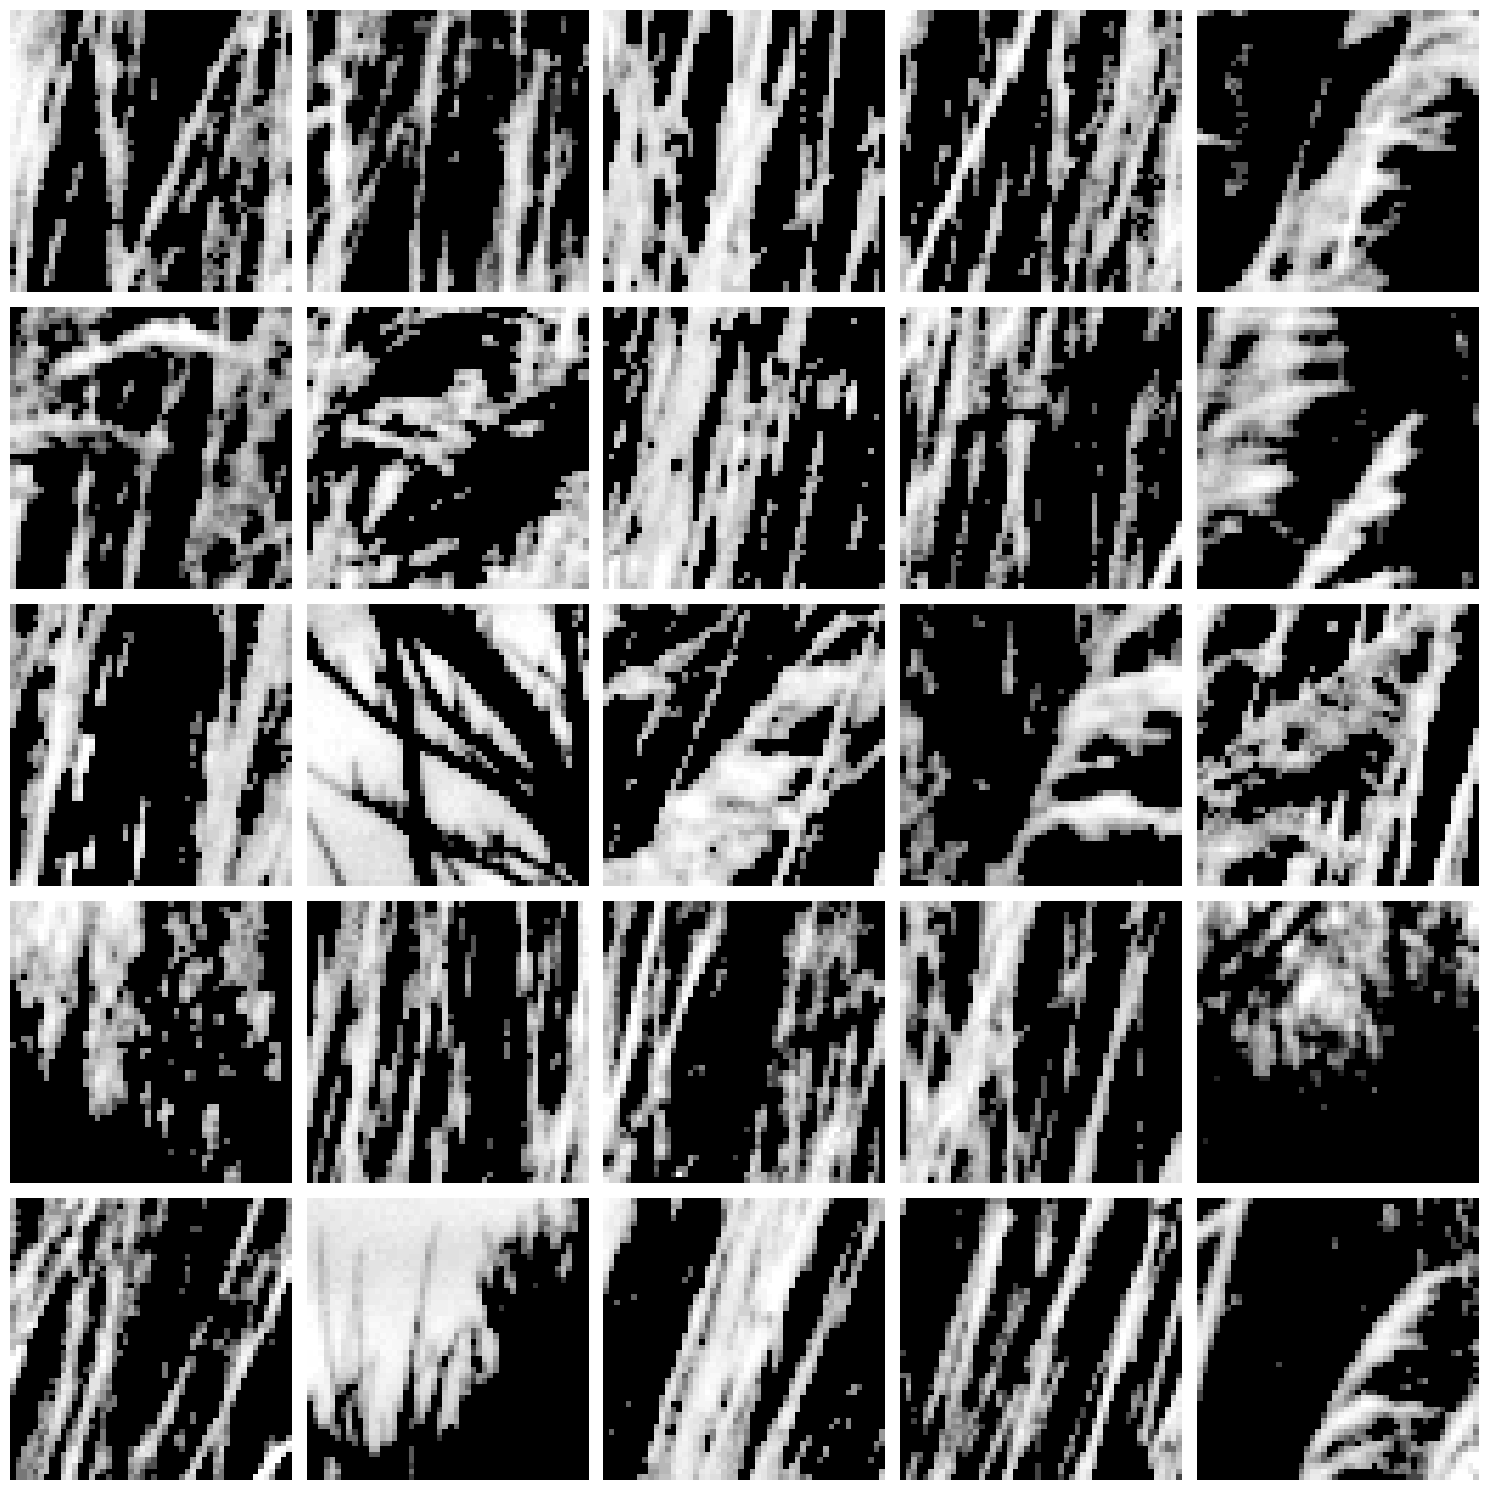

In [201]:
n_rows = 5
n_cols = 5
n_samples = n_rows * n_cols

fig, axes = plt.subplots(
    n_rows, 
    n_cols, 
    figsize=(3 * n_cols, 3 * n_rows)
)

axes = np.atleast_2d(axes)

for idx, ax in enumerate(axes.flat[:n_samples]):

    patch = patches[idx, :, :]
    show_hdr(patch, ax=ax)

for ax in axes.flat[n_samples:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [202]:
X = patches.reshape(len(patches), -1)      # (N, 2500)
dataset_mean = X.mean(axis=0)              # the "mean patch", should be ~flat/near-zero
X -= dataset_mean

from sklearn.decomposition import PCA
import numpy as np
# Initialize PCA to keep 2 components
pca = PCA(n_components=X.shape[1]-1)
# Fit and transform the data
X_reduced = pca.fit_transform(X)
lam = pca.explained_variance_
k = np.arange(1, len(lam) + 1)
alpha = -np.polyfit(np.log(k[1:500]), np.log(lam[1:500]), 1)[0]
print("spectral exponent alpha ≈", alpha)   # expect ~0.8–1.2


spectral exponent alpha ≈ 1.2604968206856348


In [203]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [1.0397733e-01 8.9056566e-02 4.4180762e-02 ... 2.3197035e-06 2.2730965e-06
 2.2589254e-06]
Cumulative: [0.10397733 0.1930339  0.23721467 ... 0.9999951  0.9999974  0.99999964]


Text(0, 0.5, 'Variance')

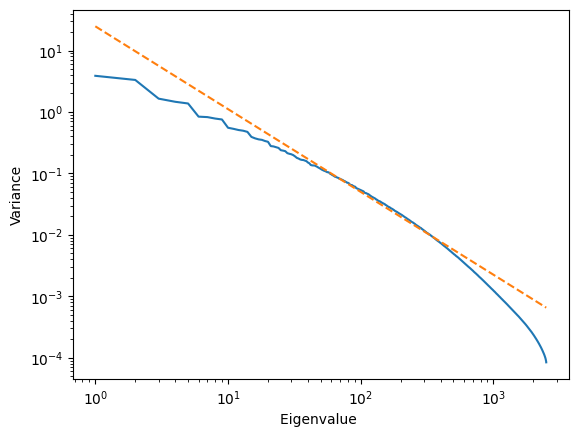

In [207]:
plt.loglog(np.arange(1, len(pca.explained_variance_)+1), 
           pca.explained_variance_)
x = np.linspace(1, X.shape[1]-1)
k = np.arange(1, len(lam)+1)
b, c = np.polyfit(np.log(k[20:500]), np.log(lam[20:500]), 1)
plt.loglog(x, np.exp(c) * x**b, '--')
plt.xlabel("Eigenvalue ")
plt.ylabel("Variance")

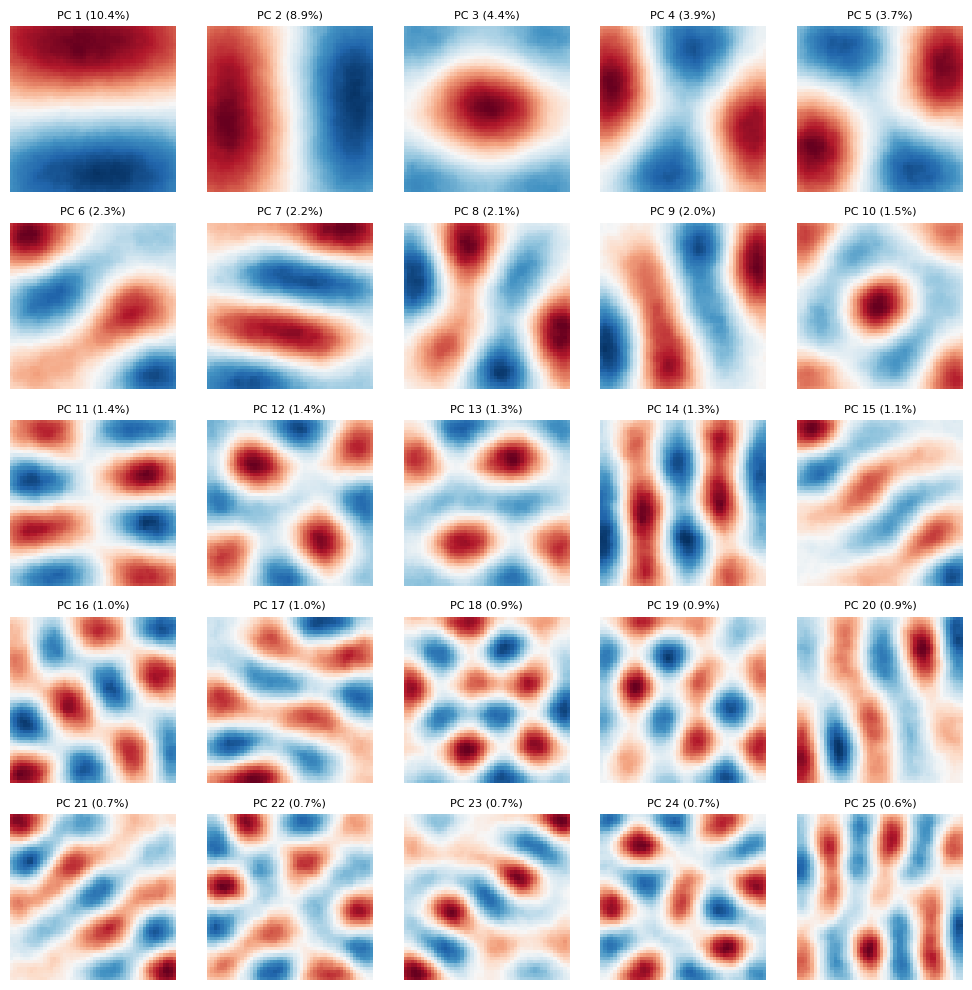

In [208]:
n_show = 25
n_rows, n_cols = 5, 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))

for i, ax in enumerate(axes.flat[:n_show]):
    eigvec = pca.components_[i].reshape(patch_size)
    vmax = np.abs(eigvec).max()
    ax.imshow(eigvec, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"PC {i+1} ({pca.explained_variance_ratio_[i]:.1%})", fontsize=8)
    ax.set_axis_off()

for ax in axes.flat[n_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

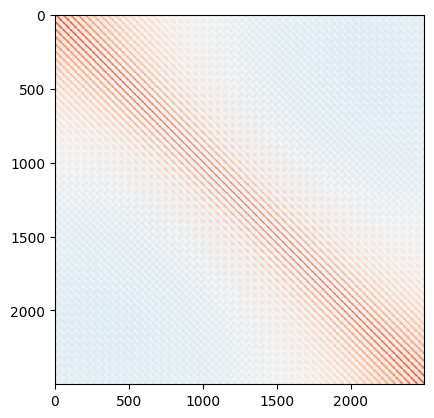

In [209]:
D = pca.get_covariance()
plt.imshow(D, cmap='RdBu_r', vmin=-np.abs(D).max(), vmax=np.abs(D).max())

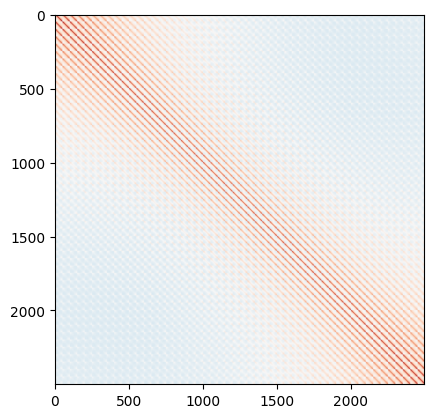

In [210]:
n_patches = patches.shape[0]
X = patches.reshape(n_patches, -1)  
X = X - X.mean(0)
C = np.cov(X, rowvar=False)        
plt.imshow(C, cmap='RdBu_r', vmin=-np.abs(C).max(), vmax=np.abs(C).max())

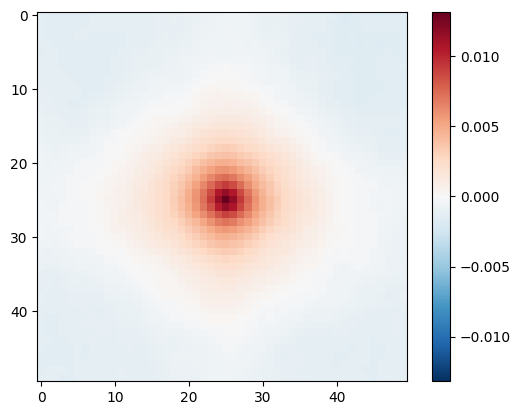

In [211]:
P = 50
c = (P//2)*P + (P//2)
acf = C[c].reshape(P, P)

m = np.abs(acf).max()
plt.imshow(acf, cmap='RdBu_r', vmin=-m, vmax=m); plt.colorbar()

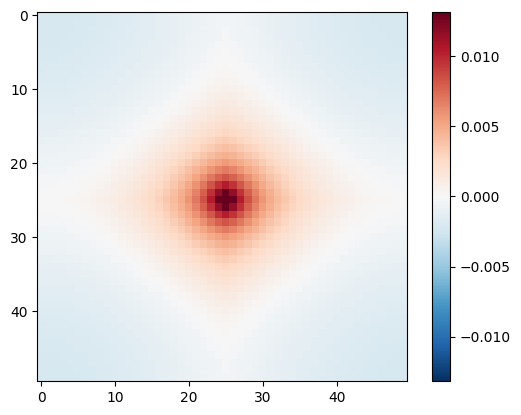

In [212]:
acf = np.zeros((P, P))
for i in range(P):
    for j in range(P):
        acf += np.roll(C[i*P + j].reshape(P, P), (P//2 - i, P//2 - j), axis=(0, 1))
acf /= P * P
plt.imshow(acf, cmap='RdBu_r', vmin=-m, vmax=m); plt.colorbar()

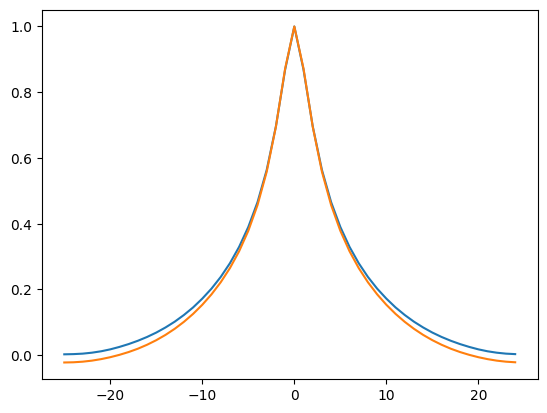

In [213]:
rx = acf[P//2, :] / acf[P//2, P//2]      # horizontal
ry = acf[:, P//2] / acf[P//2, P//2]      # vertical
d = np.arange(P) - P//2
plt.plot(d, rx)
plt.plot(d, ry)

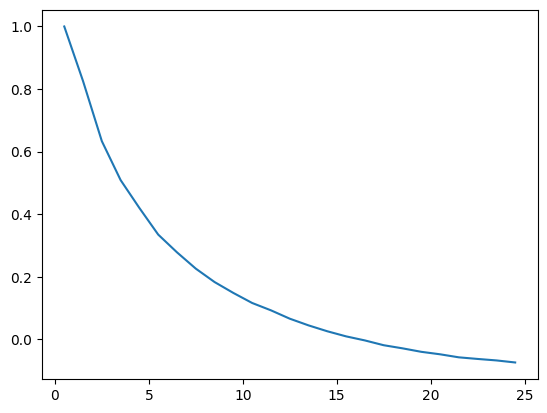

In [214]:
yy, xx = np.mgrid[0:P, 0:P] - P//2
dist = np.hypot(xx, yy).ravel()
bins = np.arange(0, P//2 + 1)
prof = np.array([acf.ravel()[(dist >= b) & (dist < b+1)].mean() for b in bins[:-1]])
plt.plot(bins[:-1] + 0.5, prof / prof[0])

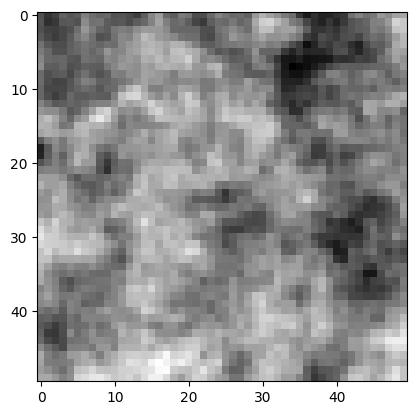

In [215]:
### PCA as generative model img ~ p(s)

coef = np.random.randn(pca.n_components_) * np.sqrt(pca.explained_variance_)
img  = (coef @ pca.components_ + pca.mean_).reshape(P,P)
plt.imshow(img, cmap='gray')

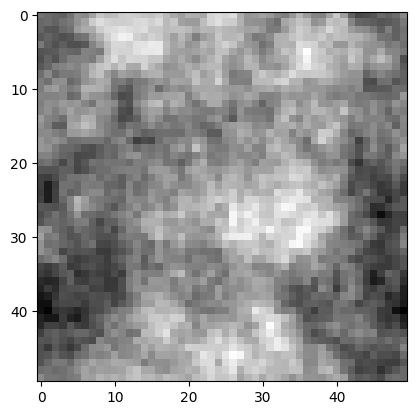

In [216]:
## 1/f gen model
N = 50
fy, fx = np.meshgrid(np.fft.fftfreq(N), np.fft.fftfreq(N), indexing='ij')
f = np.hypot(fx, fy); f[0,0] = 1
spec = np.fft.fft2(np.random.randn(N, N)) / f**(alpha)      # amplitude ~ 1/f, power ~ 1/f²
img = np.real(np.fft.ifft2(spec))
plt.imshow(img, cmap='gray')

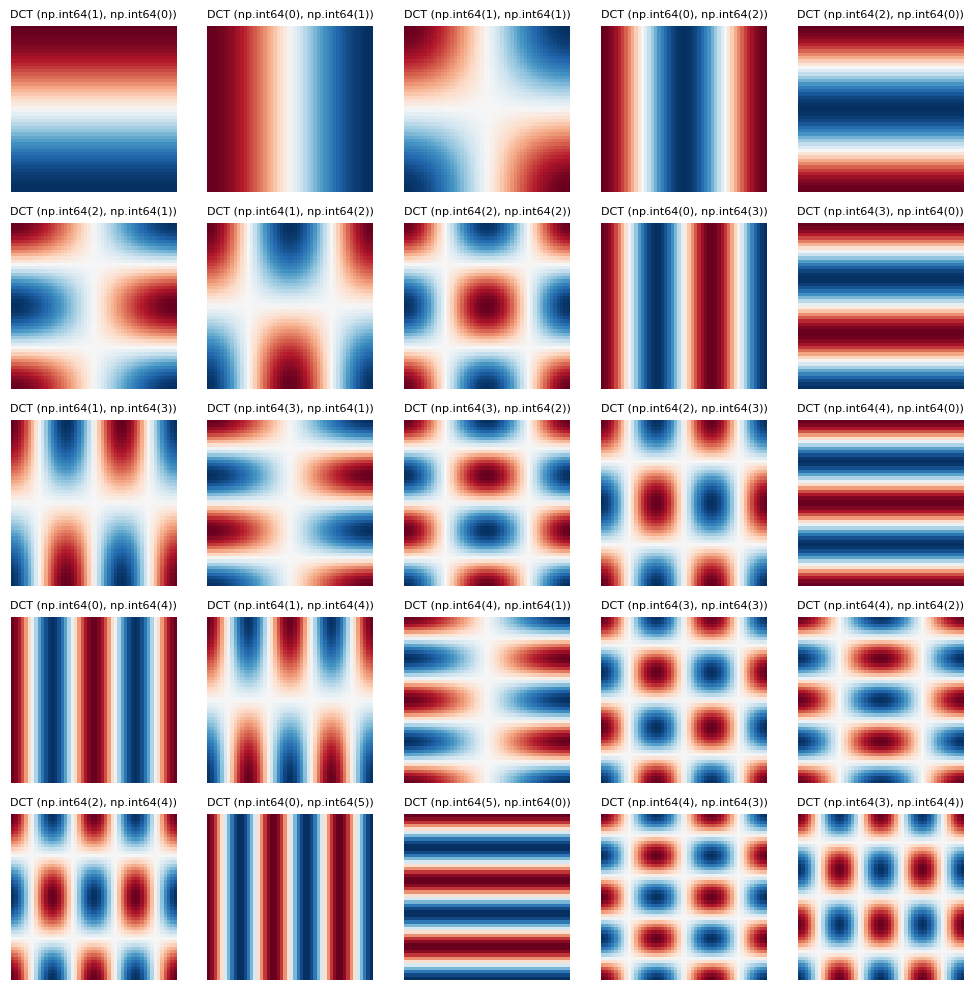

In [221]:
from scipy.fft import idctn

P = patch_size[0]
ky, kx = np.indices((P, P))
order = np.argsort(np.hypot(kx, ky).ravel())      # sort modes by radial frequency

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    i+=1
    basis = np.zeros(P*P); basis[order[i]] = 1
    b = idctn(basis.reshape(P, P), norm='ortho')
    v = np.abs(b).max()
    ax.imshow(b, cmap='RdBu_r', vmin=-v, vmax=v)
    ax.set_title(f"DCT {tuple(np.unravel_index(order[i], (P,P)))}", fontsize=8)
    ax.set_axis_off()
plt.tight_layout()

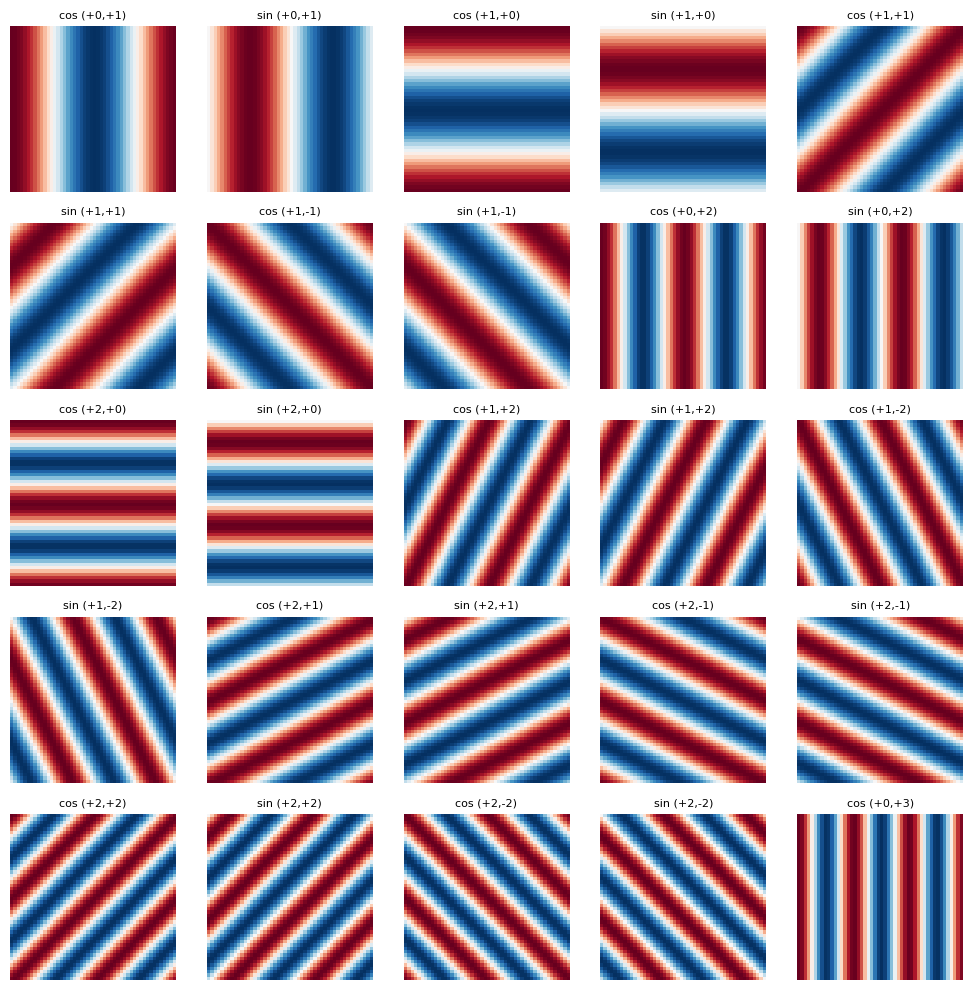

In [222]:
P = patch_size[0]
y, x = np.indices((P, P))
freqs = np.fft.fftfreq(P) * P          # integer cycles-per-patch, signed

# half-plane only: (fy,fx) and (-fy,-fx) are conjugates, same real modes
pairs = [(fy, fx) for fy in freqs for fx in freqs
         if (fy > 0) or (fy == 0 and fx > 0)]
pairs.sort(key=lambda p: np.hypot(*p))

modes = []
for fy, fx in pairs:
    ph = 2*np.pi*(fy*y + fx*x)/P
    modes.append((np.cos(ph), f"cos ({fy:+.0f},{fx:+.0f})"))
    modes.append((np.sin(ph), f"sin ({fy:+.0f},{fx:+.0f})"))

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, (b, lab) in zip(axes.flat, modes):
    v = np.abs(b).max()
    ax.imshow(b, cmap='RdBu_r', vmin=-v, vmax=v)
    ax.set_title(lab, fontsize=8)
    ax.set_axis_off()
plt.tight_layout()